# 03. 모델 활용 방안

In [4]:
%load_ext autoreload
%autoreload 2

import sys, json, pickle
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src.data import load_raw, clean
from src.features import to_long, build_features
from src.viz import setup_plot_style, DOW_KR

setup_plot_style()
pd.set_option("display.max_columns", 50)
DATA, OUT = ROOT / C.DATA_PATH, ROOT / C.OUTPUT_DIR

required = ["predictions_test.csv", "run_info.json", C.FINAL_MODEL_FILE]
missing = [f for f in required if not (OUT / f).exists()]
if missing:
    raise FileNotFoundError(f"run.py 실행 결과가 없습니다: {missing}")

preds = pd.read_csv(OUT / "predictions_test.csv", parse_dates=["ts", "date"])
info = json.loads((OUT / "run_info.json").read_text(encoding="utf-8"))
selected = info["selected_model"]
with open(OUT / C.FINAL_MODEL_FILE, "rb") as f:
    model = pickle.load(f)
feat = build_features(to_long(clean(load_raw(DATA))[0]))
print("선정 모델:", selected)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
선정 모델: lstm_1d


## 1. 테스트 구간 예측 (1주)

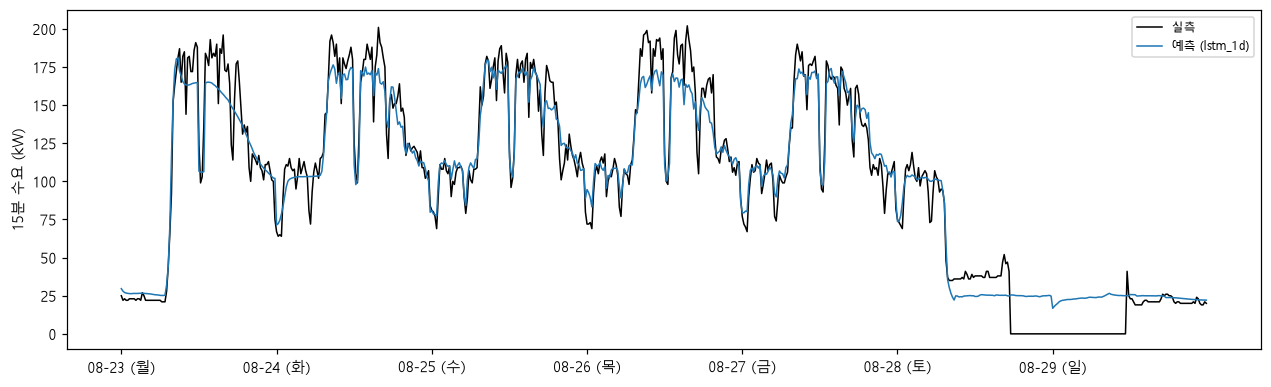

In [3]:
week = pd.date_range(preds["date"].min(), periods=7, freq="D")
w = preds[preds["date"].isin(week)]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(w["ts"], w["kw"], color="black", lw=1, label="실측")
ax.plot(w["ts"], w[selected], color="tab:blue", lw=1, label=f"예측 ({selected})")
ax.set_xticks(week)
ax.set_xticklabels([f"{d:%m-%d} ({DOW_KR[d.dayofweek + 1]})" for d in week])
ax.set_ylabel("15분 수요 (kW)")
ax.legend(fontsize=8, loc="upper right")
plt.show()

## 피크 감소 방안

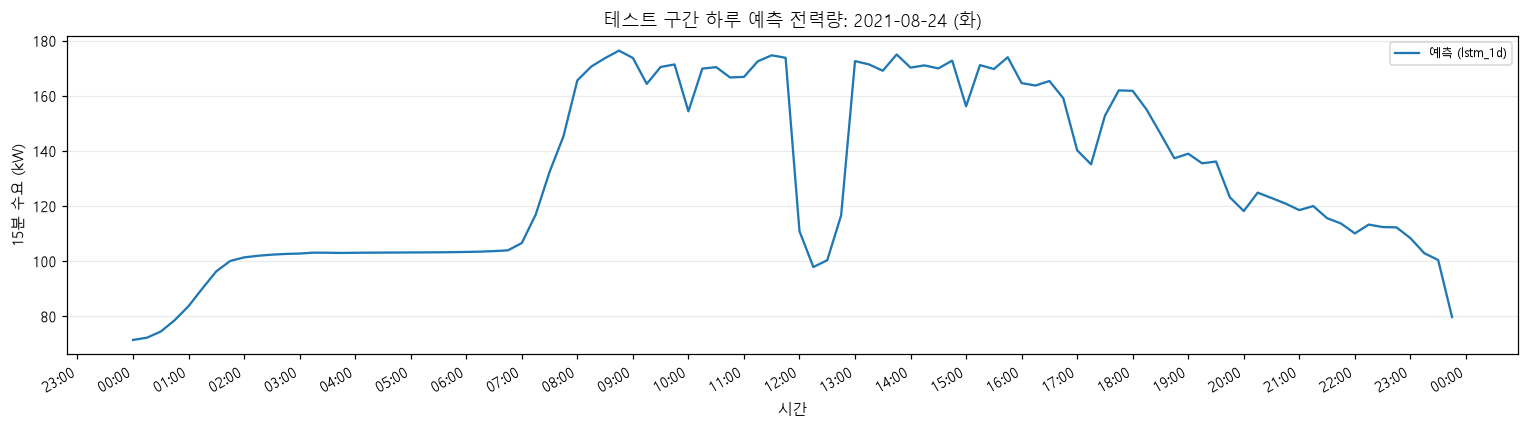

예측 하루 전력량: 3,145.93 kWh


In [8]:
available_dates = sorted(preds["date"].dropna().unique())
if len(available_dates) < 2:
    raise ValueError("테스트 구간에 날짜가 2개 이상 필요합니다.")
TEST_DATE = pd.Timestamp(available_dates[1])

if TEST_DATE not in set(preds["date"].dropna().unique()):
    available_dates_text = [d.strftime("%Y-%m-%d") for d in available_dates]
    raise ValueError(f"TEST_DATE가 테스트 구간에 없습니다: {TEST_DATE:%Y-%m-%d}\n사용 가능한 날짜: {available_dates_text}")

day = preds.loc[preds["date"].eq(TEST_DATE)].sort_values("ts").copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(day["ts"], day[selected], color="tab:blue", lw=1.5, label=f"예측 ({selected})")
ax.set_title(f"테스트 구간 하루 예측 전력량: {TEST_DATE:%Y-%m-%d} ({DOW_KR[TEST_DATE.dayofweek + 1]})")
ax.set_xlabel("시간")
ax.set_ylabel("15분 수요 (kW)")
ax.xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 15분 단위 예측 수요를 에너지로 환산한 하루 합계(kWh)입니다.
print(f"예측 하루 전력량: {day[selected].sum() * 0.25:,.2f} kWh")

예측 그래프를 보면 아침시간은 낮은 전력량, 일반적인 출근 시간이 09:00~18:00 구간에서 비교적 높은 전력량을 보이다 점차 낮아지는 추세를 보인다. 또한 점심시간인 12:00~12:00 구간은 전력량이 급격하게 감소하는 모습을 보인다.

가장 전력량이 높은 피크 지점은 낮 시간에 주로 나타나며, 전력량이 고르지 않고 급격하게 높거나 낮은 지점이 보이는 점을 감안하였을 때, 이를 서로 보완해준다면 피크 전력량을 낮출 수 있을 것으로 예상된다.